In [1]:
import warnings

import astropy.units
import FunctionLib as FL
import inspect
from tqdm import tqdm
import astropy
import wave
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict
import re
import scipy

mpl.rcParams['font.family'] = 'serif'

filepath=os.path.expanduser('~/DJAv4')
warnings.filterwarnings("ignore")

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(os.path.expanduser(
    './DJAv4Catalog.pkl'))
print(DJAv4Catalog.sample_num())

DJAv4Catalog.to_dataframe()

459


,survey_id_subid,survey_id,prism_filepath,prism_redshift,grating_filepaths,grating_redshifts,determined_redshift,file_count,available_filters,properties
0,snh0pe-v4_4446_102,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",0.2259,3,"{g140m-f100lp, g235m-f170lp, prism-clear}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
1,snh0pe-v4_4446_143,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.6318,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",1.6311,3,"{g140m-f100lp, g235m-f170lp, prism-clear}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
2,snh0pe-v4_4446_285,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,0.4446,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': 0.4462, 'g235m-f170lp': 0.4462}",0.4462,3,"{g140m-f100lp, g235m-f170lp, prism-clear}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
3,snh0pe-v4_4446_29,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.7834,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",1.77975,3,"{g140m-f100lp, g235m-f170lp, prism-clear}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
4,snh0pe-v4_4446_123,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",1.7855,3,"{g140m-f100lp, g235m-f170lp, prism-clear}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
...,...,...,...,...,...,...,...,...,...,...
32564,ceers-ddt-v4_2750_1636,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,3.0592,{},{},3.0592,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32565,ceers-ddt-v4_2750_3213,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,4.8013,{},{},4.8013,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32566,ceers-ddt-v4_2750_340,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,0.9585,{},{},0.9585,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32567,ceers-ddt-v4_2750_21413,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,2.1402,{},{},2.1402,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."


In [39]:
def estimate_snr_error(spectrum_1d,fitter_fit_result, line_center_wavelength,continuum_width=150*astropy.units.AA, measureLengthInFWHM=3, n_random_samples=1000, plot_diagnostics=False):
    """
    Estimate the continuum uncertainty using the linefitter object.

    Parameters
    ----------
    linefitter : LineFitter
        The linefitter object containing the spectrum and fitted lines.
    continuum_width : astropy.units.Quantity, optional
        The width of the continuum region to use for SNR estimation, by default 150 * astropy.units.AA
    sigma_range : int, optional
        The number of standard deviations to consider for the noise estimation, by default 3
    n_random_samples : int, optional
        The number of random samples to use for noise estimation, by default 1000
    plot_diagnostics : bool, optional
        Whether to plot diagnostic figures, by default False

    Returns
    -------
    dict
        A dictionary containing the estimated SNR error and other relevant information.
        - 'continuum_std': The standard deviation of the continuum region.
        - 'random_integrals': The random integrals used for uncertainty estimation.
        - 'snr_error': The estimated SNR error.
        - 'continuum_region': The wavelength range of the continuum region.
    """

    continuum_width=continuum_width.to(astropy.units.AA)
    line_center_wavelength = line_center_wavelength.to(astropy.units.AA)

    line_center_wavelength= fitter_fit_result['parameters']['mean'].to(astropy.units.AA)
    fitted_curve= fitter_fit_result['fitted_curve']
    sigma= fitter_fit_result['parameters']['stddev'].to(astropy.units.AA)

    measure_range= measureLengthInFWHM * 2.355*sigma

    half_width= continuum_width / 2
    continuum_start_region = (line_center_wavelength - half_width, line_center_wavelength + half_width- measure_range)

    #spectrum_1d.set_boundarys(continuum_start_region[0], continuum_start_region[1]+ measure_range)

    continuum_sampling_region = spectrum_1d.dual_boundarys(if_process=True,unit=astropy.units.AA)

    indices = (spectrum_1d.restframe_wavelengths.convert_unit_to(astropy.units.AA).data >= continuum_start_region[0].value) & (spectrum_1d.restframe_wavelengths.convert_unit_to(astropy.units.AA).data <= continuum_start_region[1].value)

    continuumStartRegionWavelengths = spectrum_1d.restframe_wavelengths[indices]

    continuumStartRegionWavelengths = continuumStartRegionWavelengths.convert_unit_to(astropy.units.AA)

    residual_flux=fitter_fit_result['residual_flux'].data

    #plt.plot(spectrum_1d.processing_wavelengths.data, residual_flux)

    np.random.seed(42)  # For reproducibility
    random_integrals = []
    for _ in range(n_random_samples):
        start_idx=np.random.randint(0, (continuumStartRegionWavelengths).data.shape[0]-1)

        random_start = continuumStartRegionWavelengths.data[start_idx]
        random_end = random_start + continuum_width.value
        random_integrals.append(
            np.trapz(
                residual_flux[
                    (spectrum_1d.processing_wavelengths.convert_unit_to(astropy.units.AA).data >= random_start) &
                    (spectrum_1d.processing_wavelengths.convert_unit_to(astropy.units.AA).data <= random_end)
                ],
                x=spectrum_1d.processing_wavelengths[
                    (spectrum_1d.processing_wavelengths.convert_unit_to(astropy.units.AA).data >= random_start) &
                    (spectrum_1d.processing_wavelengths.convert_unit_to(astropy.units.AA).data <= random_end)
                ]
            )
        )


    return random_integrals



def fitting_uncertainty(fit_result):
    covariance = fit_result['covariance']

# 提取相关参数的不确定性
    var_A = covariance[0,0]         # = 3.10e-35
    var_sigma = covariance[2,2]     # = 9.98e-01
    cov_A_sigma = covariance[0,2]   # = -3.05e-18

    sigma_A = np.sqrt(var_A)        # = 5.59e-18
    sigma_sigma = np.sqrt(var_sigma) # = 0.999

# print(f"Parameter Uncertainty:")
# print(f"σ_A = {sigma_A:.2e}, A = {fit_result['parameters']['amplitude'].value:.2e}, Percentage = {sigma_A/fit_result['parameters']['amplitude'].value*100:.2f}%")
# print(f"σ_sigma = {sigma_sigma:.3f}, sigma = {fit_result['parameters']['stddev'].value:.3f}, Percentage = {sigma_sigma/fit_result['parameters']['stddev'].value*100:.2f}%")

# 高斯积分流量：F = A * sigma * sqrt(2*pi)
    A = fit_result['parameters']['amplitude'].value
    sigma = fit_result['parameters']['stddev'].value
    sqrt_2pi = np.sqrt(2 * np.pi)

# 验证积分流量
    flux_calculated = A * sigma * sqrt_2pi
#  print(f"Integrated Flux: {flux_calculated:.3e}")

# 误差传播公式：σ_F² = (∂F/∂A)²σ_A² + (∂F/∂σ)²σ_σ² + 2(∂F/∂A)(∂F/∂σ)cov_A_σ
    dF_dA = sigma * sqrt_2pi
    dF_dsigma = A * sqrt_2pi

    flux_variance = (dF_dA**2 * var_A +
                    dF_dsigma**2 * var_sigma +
                    2 * dF_dA * dF_dsigma * cov_A_sigma)

    fitting_uncertainty = np.sqrt(flux_variance)

    return fitting_uncertainty, flux_calculated
# print(f"\nFitting Uncertainty Analysis:")
# print(f"Integrated Flux: {flux_calculated:.3e} erg/(s·cm²)")
# print(f"Fitting Uncertainty: {fitting_uncertainty:.3e} erg/(s·cm²)")
# print(f"Relative Error: {fitting_uncertainty/flux_calculated*100:.1f}%")


def calculate_err_at_given_wavelength(Spectrum_1d, RestFrameWavelength):

    Spectrum_1d.set_boundarys(RestFrameWavelength-75*astropy.units.AA, RestFrameWavelength+75*astropy.units.AA)

    spectralLineFitter=FL.SpectralLineFitter(Spectrum_1d,RestFrameWavelength)

    fit_result=spectralLineFitter.fit_single_gaussian_with_offset()

    fitting_uncertainty_value, flux_calculated=fitting_uncertainty(fit_result)

    error_array=estimate_snr_error(Spectrum_1d, fit_result, fit_result['parameters']['mean'].to(astropy.units.AA), continuum_width=150*astropy.units.AA, measureLengthInFWHM=2, n_random_samples=20)

    err=np.std(error_array)



    return np.sqrt(fitting_uncertainty_value**2 + err**2), flux_calculated

In [40]:
for id, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['properties'].get('Sample_Flag', False):
        continue
    try:
        prism_filepath = os.path.expanduser('~/' + catalog['prism_filepath'][16:])
        for filter, grating_filepath in catalog['grating_filepaths'].items():
            Halpha_Flag=False
            AlphaLineErrorList=list()
            AlphaLineFluxList=list()

            Hbeta_Flag=False
            BetaLineErrorList=list()
            BetaLineFluxList=list()

            grating_filepath = os.path.expanduser('~/' + grating_filepath[16:])
            grating_spectrum=FL.Load_Spectrum_From_Fits(grating_filepath,catalog['determined_redshift'])
            inf,sup= grating_spectrum.dual_boundarys()
            if inf< 6563.0*astropy.units.AA and sup>6563.0*astropy.units.AA:
                Halpha_Flag=True
            if inf< 4863.0*astropy.units.AA and sup>4863.0*astropy.units.AA:
                Hbeta_Flag=True

            if Halpha_Flag:
                restframeWavelength=6563.0*astropy.units.AA
                grating_spectrum.set_boundarys(restframeWavelength-75*astropy.units.AA, restframeWavelength+75*astropy.units.AA)
                AlphaLineError, AlphaLineFlux=calculate_err_at_given_wavelength(grating_spectrum, restframeWavelength)
                AlphaLineErrorList.append(AlphaLineError)
                AlphaLineFluxList.append(AlphaLineFlux)

            if Hbeta_Flag:
                restframeWavelength=4863.0*astropy.units.AA
                grating_spectrum.set_boundarys(restframeWavelength-75*astropy.units.AA, restframeWavelength+75*astropy.units.AA)
                BetaLineError, BetaLineFlux=calculate_err_at_given_wavelength(grating_spectrum, restframeWavelength)
                BetaLineErrorList.append(BetaLineError)
                BetaLineFluxList.append(BetaLineFlux)

        AlphaLineError = np.array(AlphaLineErrorList)
        AlphaLineFlux = np.array(AlphaLineFluxList)

        BetaLineError = np.array(BetaLineErrorList)
        BetaLineFlux = np.array(BetaLineFluxList)


        if len(AlphaLineError) > 0:
            catalog['properties']['Halpha_Error'] = np.nanmax(AlphaLineError)
            catalog['properties']['Halpha_Flux'] = AlphaLineFlux[np.nanargmax(AlphaLineError)]

        if len(BetaLineError) > 0:
            catalog['properties']['Hbeta_Error'] = np.nanmax(BetaLineError)
            catalog['properties']['Hbeta_Flux'] = BetaLineFlux[np.nanargmax(BetaLineError)]
    except Exception as e:
        print(f"Error processing catalog {id}: {e}")

    DJAv4Catalog.update_catalog_item(id,catalog)


Error processing catalog jades-gdn2-v4_1181_920: All-NaN slice encountered
Error processing catalog rubies-uds42-v4_4233_14629: All-NaN slice encountered
Error processing catalog ceers-v4_1345_1626: All-NaN slice encountered
Error processing catalog ceers-v4_1345_4385: All-NaN slice encountered
Error processing catalog ceers-v4_1345_4210: All-NaN slice encountered
Error processing catalog ceers-v4_1345_1651: All-NaN slice encountered
Error processing catalog rubies-egs62-v4_4233_48483: All-NaN slice encountered
Error processing catalog rubies-uds31-v4_4233_947203: All-NaN slice encountered
Error processing catalog jades-gds04-v4_1286_30053944: high <= 0
Error processing catalog jades-gds04-v4_1286_167639: All-NaN slice encountered
Error processing catalog jades-gds-wide3-v4_1180_126180: All-NaN slice encountered
Error processing catalog rubies-uds23-v4_4233_181919: high <= 0
Error processing catalog rubies-uds23-v4_4233_150496: high <= 0
Error processing catalog gds-udeep-v4_3215_20185

In [43]:
mean=list()
error=list()
redshift=list()
def err(alphaValve, alphaError, betaValve, betaError):
    err_ratio=alphaError**2/alphaValve**2 + betaError**2/betaValve**2
    return np.sqrt(err_ratio)

for id, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['properties'].get('Sample_Flag', False):
        continue
    if not catalog['properties'].get('Halpha_Error', False):
        continue
    if not catalog['properties'].get('Halpha_Flux', False):
        continue
    if not catalog['properties'].get('Hbeta_Error', False):
        continue
    if not catalog['properties'].get('Hbeta_Flux', False):
        continue

    mean.append(catalog['properties']['Halpha_Flux']/catalog['properties']['Hbeta_Flux'])
    error.append(err(catalog['properties']['Halpha_Flux'], catalog['properties']['Halpha_Error'],
                     catalog['properties']['Hbeta_Flux'], catalog['properties']['Hbeta_Error']))
    redshift.append(catalog['determined_redshift'])


In [44]:
error

[np.float64(0.04896106189515065),
 np.float64(0.028514142427104282),
 np.float64(0.35795813272113425),
 np.float64(342530.30136990873),
 np.float64(0.13385758882160143),
 np.float64(0.14396120532401432),
 np.float64(0.0713660219644598),
 np.float64(0.28414331882421157),
 np.float64(63604.33148029271),
 np.float64(0.1314210024999962),
 np.float64(0.06688705836428833),
 np.float64(2295.717230191878),
 np.float64(0.22964702089678668),
 np.float64(0.19924344999925148),
 np.float64(0.0866869761208706),
 np.float64(0.538680987161093),
 np.float64(0.19174972411778876),
 np.float64(0.19109833909617674),
 np.float64(15883.590982930833),
 np.float64(10036.135049915943),
 np.float64(250010461.19735053),
 np.float64(0.1575862945113737),
 np.float64(0.6381410697258435),
 np.float64(0.0955543621932216),
 np.float64(0.30484110211922183),
 np.float64(0.07700300891736209),
 np.float64(0.1755673968876014),
 np.float64(0.14888511490092413),
 np.float64(0.19941313727057555),
 np.float64(0.3306796270243064

In [1]:
plt.figure(figsize=(30,10))
for i in range(len(error)):
    if error[i]>0.1:
        continue
    plt.scatter(redshift[i], mean[i], s=10, alpha=0.5,c='k')
    plt.errorbar(redshift[i], mean[i], yerr=error[i], fmt='o', alpha=0.5)
    plt.ylim(1,5)
    plt.xlim(4,7.5)
    plt.hlines(2.88,4,7.5,color='red',linestyle='--')
    plt.xlabel('Redshift')
    plt.ylabel('Halpha/Hbeta Ratio')
    plt.title('Halpha/Hbeta Ratio vs Redshift')

NameError: name 'plt' is not defined

Text(0.5, 1.0, 'Halpha/Hbeta Ratio vs Redshift')

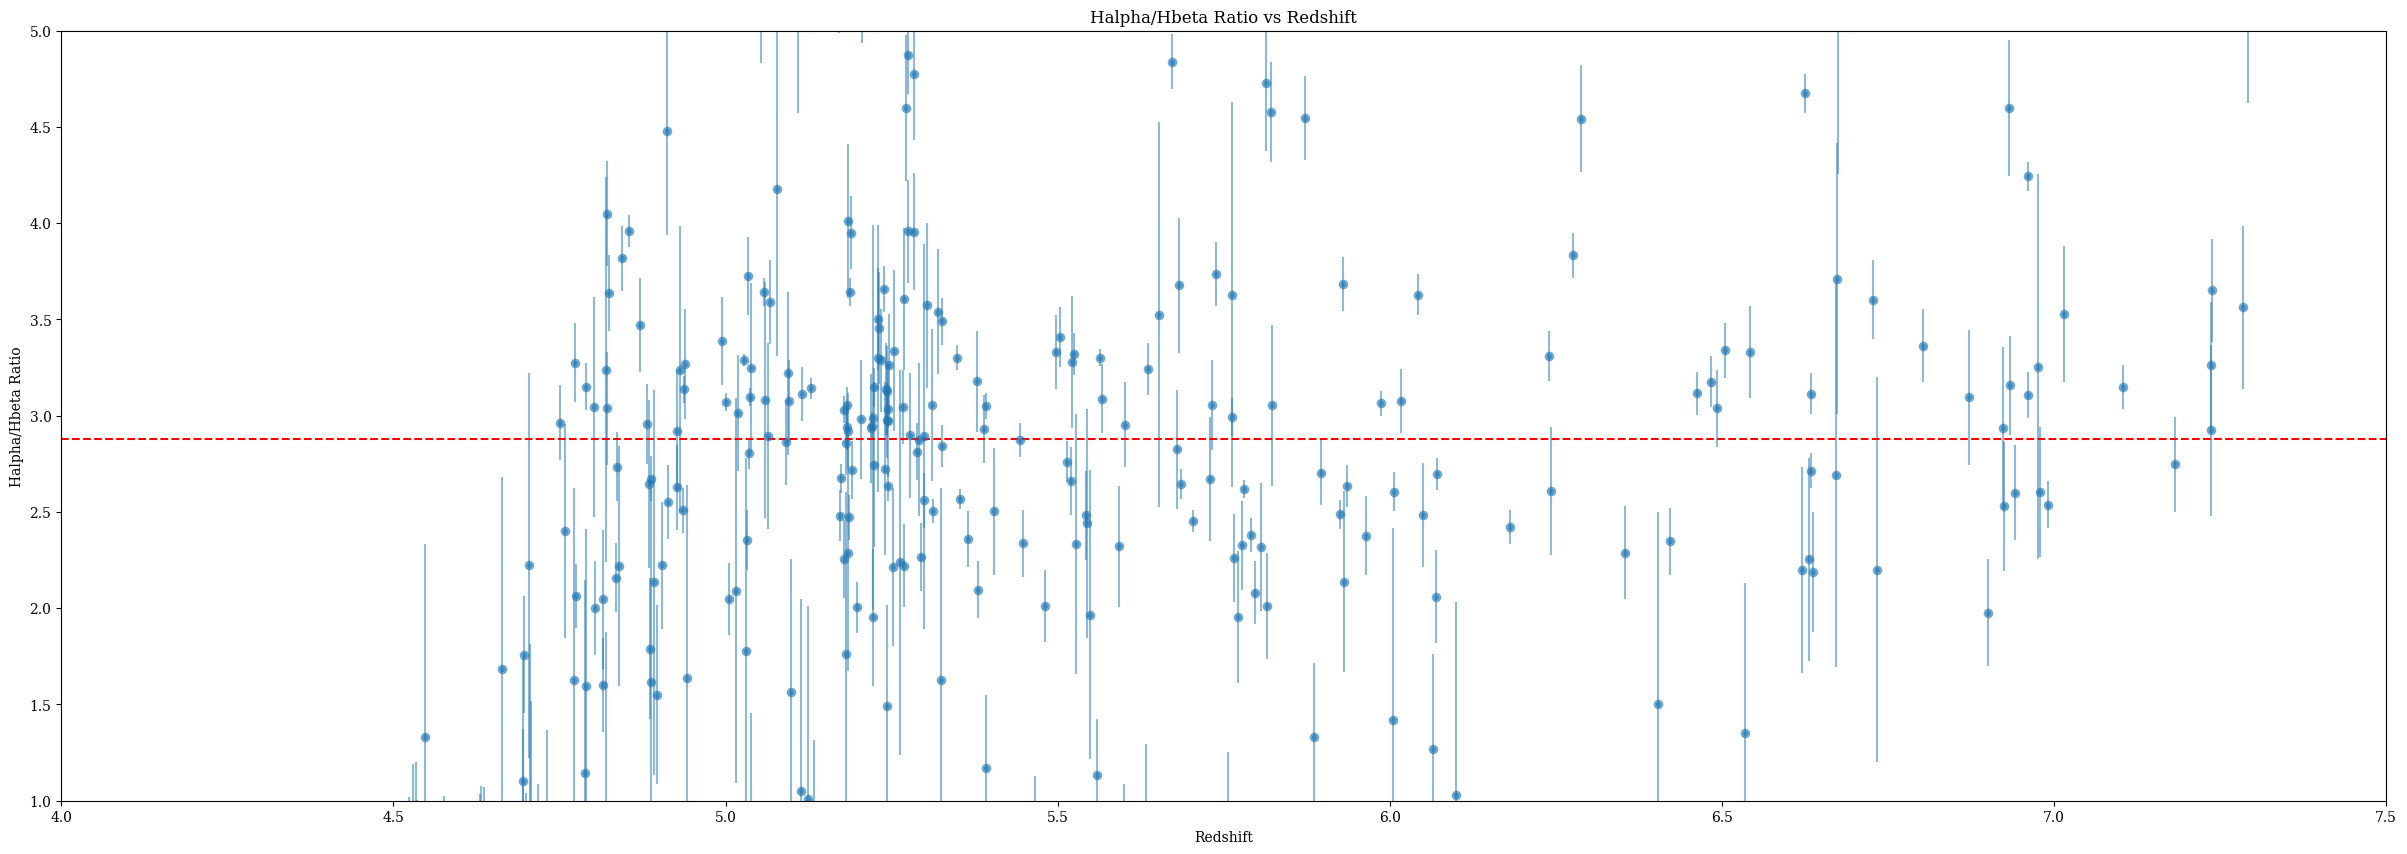

In [49]:
plt.figure(figsize=(30,10))
plt.scatter(redshift, mean, s=10,alpha=0.5)
plt.errorbar(redshift, mean, yerr=error, fmt='o', alpha=0.5)
plt.ylim(1,5)
plt.xlim(4,7.5)
plt.hlines(2.88,4,7.5,color='red',linestyle='--')
plt.xlabel('Redshift')
plt.ylabel('Halpha/Hbeta Ratio')
plt.title('Halpha/Hbeta Ratio vs Redshift')